In [1]:
import numpy as np
import pandas as pd

def aggregate_de_results(
    df,
    group_col="symbol",
    strata_col="level_0",
    lfc_col="log2FoldChange",
    se_col="lfcSE",
    basemean_col="baseMean",
):
    """
    Aggregate DE results across strata (e.g. level_0) for each gene/symbol
    using empirical Bayes-style inverse-variance weighting.

    Returns:
        DataFrame with:
            symbol
            log2FoldChange   # EB pooled estimate
            lfcSE            # pooled SE
            baseMean         # mean baseMean across strata
            n_strata
    """

    def _aggregate_group(g):
        # remove invalid rows
        g = g[
            np.isfinite(g[lfc_col]) &
            np.isfinite(g[se_col]) &
            (g[se_col] > 0)
        ].copy()

        if len(g) == 0:
            return pd.Series({
                "log2FoldChange": np.nan,
                "lfcSE": np.nan,
                "baseMean": np.nan,
                "n_strata": 0,
            })

        # observed effects + variances
        y = g[lfc_col].values
        v = g[se_col].values ** 2

        # ---- empirical Bayes random-effects shrinkage ----
        # DerSimonian-Laird estimate for between-study variance tau^2

        w_fixed = 1 / v
        mu_fixed = np.sum(w_fixed * y) / np.sum(w_fixed)

        Q = np.sum(w_fixed * (y - mu_fixed) ** 2)
        df_Q = len(y) - 1

        C = np.sum(w_fixed) - (np.sum(w_fixed**2) / np.sum(w_fixed))

        tau2 = max(0, (Q - df_Q) / C) if C > 0 else 0

        # EB/random-effects weights
        w = 1 / (v + tau2)

        mu = np.sum(w * y) / np.sum(w)

        # pooled standard error
        se = np.sqrt(1 / np.sum(w))

        return pd.Series({
            "log2FoldChange": mu,
            "lfcSE": se,
            "baseMean": g[basemean_col].mean(),
            "n_strata": len(g),
        })

    out = (
        df.groupby(group_col, observed=True)
        .apply(_aggregate_group)
        .reset_index()
    )

    return out

In [2]:
from tqdm import tqdm
import meta_analysis
from meta_analysis.go import GeneOntologyLibraries
from meta_analysis.ot import UnbalancedSinkhorn, IterativeProportionalFitting
from meta_analysis.meta import MetaAnalysis

/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
GO_LIBRARIES = {
    "GO_BP": "GO_Biological_Process_2025",
    # "GO_MF": "GO_Molecular_Function_2025",
    # "GO_CC": "GO_Cellular_Component_2025",
    # "Reactome": "Reactome_Pathways_2024",
    # "SynGO": "SynGO_2024",
    # "WikiPathways": "WikiPathways_2024_Human",
    # "LINCS_Chem_Pert": "LINCS_L1000_Chem_Pert_Consensus_Sigs",
    # "LINCS_CRISPR": "LINCS_L1000_CRISPR_KO_Consensus_Sigs"
}

GO_TERMS = {
    k: GeneOntologyLibraries().pull_assignment_matrix(v)
    for k, v in tqdm(GO_LIBRARIES.items())
}

100%|██████████| 1/1 [00:03<00:00,  3.27s/it]


In [4]:
grey_matter_regions = [
    'Gyrus Frontalis Medius',
    'Insula',
    'Cerebellum GM',
    'Gyrus Temporalis Medius',
    'Gyrus Parietalis',
    'Anterior Cingulate Cortex',
    'Posterior Cingulate Cortex',
    'Occipital Cortex ',
    'Prefrontal Cortex '
]

white_matter_regions = [
    'Frontal WM',
    'Cerebellum WM',
    'Temporal WM',
    'Corpus Callosum',
    'Parietal WM',
    'Occipital WM'
]

In [16]:
import pathlib
import pandas as pd

output_path = pathlib.Path("/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/output/white-matter")
cell_type_libraries = pathlib.Path("/home/jhaberbe/Projects/Personal/MAY2026/cell-deconvolution/output/")

output_path.mkdir(parents=True, exist_ok=True)

for go_name, go_matrix in GO_TERMS.items():

    go_dir = output_path / go_name
    go_dir.mkdir(parents=True, exist_ok=True)

    for ct_path in cell_type_libraries.glob("*/"):
        if ct_path.stem != "serotonergic neuron":
            continue

        ct_dir = go_dir / ct_path.stem
        ct_dir.mkdir(parents=True, exist_ok=True)

        df = pd.concat({
            f.stem: pd.read_csv(f, index_col=0)
                    .drop_duplicates(subset=["symbol"])
                    .set_index("symbol")
            for f in ct_path.glob("*.csv")
        }).reset_index().query("level_0 in @white_matter_regions")

        df = aggregate_de_results(df).set_index("symbol")
        
        GO_TO_USE = go_name
        GO = go_matrix

        genes_available = df.index.intersection(GO.index)
        go_terms_available = GO.columns[GO.loc[genes_available].sum(axis=0).gt(0)]

        df = df.loc[genes_available]

        balanced_matrix = UnbalancedSinkhorn().get_balanced_matrix(
            GO.loc[genes_available, go_terms_available],
            tolerance=1e-12
        )

        break

        table = pd.DataFrame(
            MetaAnalysis().generate_meta_estimate(
                df.loc[genes_available],
                balanced_matrix.loc[genes_available, go_terms_available]
            )
        )

        table.to_csv(ct_dir / f"{go_name}_{ct_path.stem}.csv")
        balanced_matrix.to_csv(ct_dir / f"{go_name}_{ct_path.stem}_balanced.csv")
        df.to_csv(ct_dir / f"{go_name}_{ct_path.stem}_deseq.csv")

Unbalanced Sinkhorn:   2%|▏         | 22/1000 [00:02<02:07,  7.68it/s]


In [114]:
import pathlib
import numpy as np
import pandas as pd

GO_TO_USE = "GO_BP"
cell_type = "oligodendrocyte"

output_path = pathlib.Path(
    f"/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/output/grey-matter/{GO_TO_USE}/{cell_type}"
)

table = pd.read_csv(output_path / f"{GO_TO_USE}_{cell_type}.csv", index_col=0)
df = pd.read_csv(output_path / f"{GO_TO_USE}_{cell_type}_deseq.csv", index_col=0)
balanced_matrix = pd.read_csv(output_path / f"{GO_TO_USE}_{cell_type}_balanced.csv", index_col=0)

In [115]:
table["expected_change"] = (table["weights"] * np.pow(2, table["shrunken_estimate"])) - table["weights"]

In [116]:
import numpy as np
import plotly.express as px
from meta_analysis.pl import volcano_plot

In [117]:

table["symbol"] = table.index

volcano_plot(
    table,
    lfc_col="shrunken_estimate",
    pval_col="log10p_eb",
    gene_col=None,
    size_col="n_eff",
    lfc_thresh=0.25,
    pval_thresh=-np.log10(0.05 / table.shape[0]),
    x_label="log2Fold Change",
    y_label="-log10(p-value)",
    title="Volcano Plot",
    up_color="#d62728",      # red
    down_color="#1f77b4",    # blue
    ns_color="#bdbdbd",      # grey
    width=1000,
    height=750,
    size_max=40,
)

In [139]:
table.query("p_eb < 0.05 and abs(shrunken_estimate) > 0.25").sort_values(by="log10p_eb")

,weights,n_eff,naive_estimate,naive_standard_error,shrunken_estimate,shrunken_se,z_naive,z_eb,p_naive,p_eb,log10p_naive,log10p_eb,B,full_dataset_mean,full_dataset_standard_error,expected_change,symbol
Regulation of Transmembrane Transport (GO:0034762),54.341999,1.791754,0.274893,0.135654,0.255459,0.130319,2.026429,1.960266,4.272080e-02,4.996476e-02,1.369361,1.301336,0.922889,0.022872,0.22024,10.526902,Regulation of Transmembrane Transport (GO:0034...
Mesodermal Cell Differentiation (GO:0048333),15.379243,1.010754,-0.580968,0.254996,-0.443329,0.224057,2.278348,1.978647,2.270587e-02,4.785573e-02,1.643862,1.320066,0.772061,0.022872,0.22024,-4.068803,Mesodermal Cell Differentiation (GO:0048333)
Ceramide Transport (GO:0035627),43.604383,1.782986,0.315976,0.151438,0.288334,0.144120,2.086505,2.000647,3.693293e-02,4.543040e-02,1.432586,1.342653,0.905691,0.022872,0.22024,9.646555,Ceramide Transport (GO:0035627)
Morphogenesis of an Epithelium (GO:0002009),20.783312,2.794617,0.479546,0.219353,0.397665,0.198717,2.186187,2.001161,2.880195e-02,4.537507e-02,1.540578,1.343183,0.820703,0.022872,0.22024,6.596085,Morphogenesis of an Epithelium (GO:0002009)
Regulation of Actin Polymerization or Depolymerization (GO:0008064),27.689755,2.550695,0.410548,0.190038,0.355933,0.176144,2.160344,2.020692,3.074602e-02,4.331167e-02,1.512211,1.363395,0.859123,0.022872,0.22024,7.747953,Regulation of Actin Polymerization or Depolyme...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Erythrose 4-Phosphate/Phosphoenolpyruvate Family Amino Acid Catabolic Process (GO:1902222),573.616423,1.011897,0.301490,0.041753,0.299302,0.041589,7.220771,7.196680,5.169383e-13,6.169641e-13,12.286561,12.209740,0.992147,0.022872,0.22024,132.246539,Erythrose 4-Phosphate/Phosphoenolpyruvate Fami...
Tetrahydrobiopterin Metabolic Process (GO:0046146),570.225833,1.000000,0.303945,0.041877,0.301725,0.041711,7.258036,7.233643,3.927499e-13,4.702068e-13,12.405884,12.327711,0.992100,0.022872,0.22024,132.644461,Tetrahydrobiopterin Metabolic Process (GO:0046...
L-phenylalanine Metabolic Process (GO:0006558),570.472696,1.000866,0.303928,0.041868,0.301708,0.041702,7.259178,7.234792,3.894495e-13,4.662445e-13,12.409549,12.331386,0.992104,0.022872,0.22024,132.693660,L-phenylalanine Metabolic Process (GO:0006558)
L-phenylalanine Catabolic Process (GO:0006559),570.472696,1.000866,0.303928,0.041868,0.301708,0.041702,7.259178,7.234792,3.894495e-13,4.662445e-13,12.409549,12.331386,0.992104,0.022872,0.22024,132.693660,L-phenylalanine Catabolic Process (GO:0006559)


/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/meta_analysis/pl.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


(          gene      L2FC        SE  lower_ci  upper_ci  pct_contribution
 AMDHD1  AMDHD1  0.240839  0.275100 -0.298357  0.780035          0.001368
 FAH        FAH  0.244345  0.410206 -0.559659  1.048349          0.002957
 ATAT1    ATAT1 -0.140851  0.140439 -0.416112  0.134410          0.006700
 CARNS1  CARNS1  1.164120  0.303088  0.570067  1.758174          0.009981
 QDPR      QDPR  0.303945  0.125880  0.057220  0.550671          0.976419,
 <Figure size 1100x500 with 4 Axes>,
 array([[<Axes: xlabel='log2 fold change'>, <Axes: xlabel='Contribution'>],
        [<Axes: xlabel='meta log2 fold change'>, <Axes: >]], dtype=object))

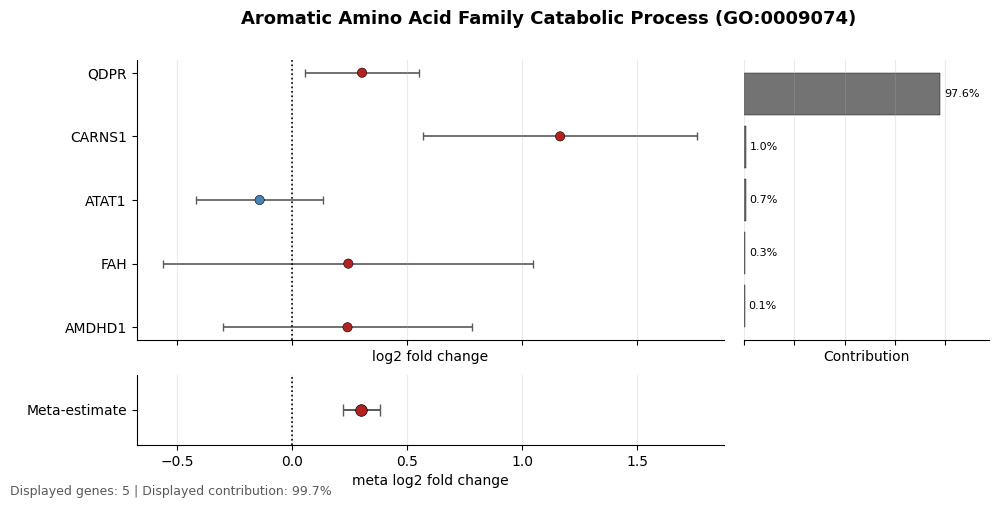

In [140]:
from meta_analysis.pl import ForestPlotter

###### SOMETHING HORRIBLE IS GOING ON HERE
ForestPlotter(df, (balanced_matrix.T * df["baseMean"]).T, table) \
    .plot_term("Aromatic Amino Acid Family Catabolic Process (GO:0009074)", cutoff=.99, minimum_kept=5)

In [141]:
from scipy.stats import norm
df["p"] = norm.sf(np.abs(df["log2FoldChange"] / df["lfcSE"])) * 2
df["log10p"] = -np.log10(df["p"])

In [142]:
df["expected_change"] = (np.pow(2, df["log2FoldChange"]) * df["baseMean"]) - df["baseMean"]

volcano_plot(
    df,
    lfc_col="expected_change",
    pval_col="log10p",
    gene_col=None,
    size_col="baseMean",
    lfc_thresh=100,
    pval_thresh=-np.log10(0.05 / df.shape[0]),
    x_label="Expected Change",
    y_label="-log10(p-value)",
    title="Volcano Plot",
    up_color="#d62728",      # red
    down_color="#1f77b4",    # blue
    ns_color="#bdbdbd",      # grey
    width=1000,
    height=750,
    size_max=40,
)

In [143]:
volcano_plot(
    df,
    lfc_col="log2FoldChange",
    pval_col="log10p",
    gene_col=None,
    size_col="baseMean",
    lfc_thresh=0.25,
    pval_thresh=-np.log10(0.05 / df.shape[0]),
    x_label="log2Fold Change",
    y_label="-log10(p-value)",
    title="Volcano Plot",
    up_color="#d62728",      # red
    down_color="#1f77b4",    # blue
    ns_color="#bdbdbd",      # grey
    width=1000,
    height=750,
    size_max=40,
)

In [144]:
df.query("log2FoldChange > 0.25 and log10p > 6").sort_values(by="log10p").tail(30).index

Index(['COL9A2', 'GSN'], dtype='str')

In [145]:
df[df.index.str.contains("HDAC")].sort_values(by="log10p")

,log2FoldChange,lfcSE,baseMean,n_strata,p,log10p,expected_change
HDAC1,0.005545,0.317893,18.608637,9.0,0.986084,0.006086,0.071656
HDAC9,-0.040561,0.528963,13.722197,9.0,0.938878,0.027391,-0.380422
HDAC4,0.139764,0.503815,11.369180,9.0,0.781464,0.107091,1.156528
HDAC2,0.058892,0.174297,73.216726,9.0,0.735451,0.133446,3.050625
HDAC3,0.210441,0.462467,27.659211,9.0,0.649080,0.187702,4.343663
HDAC11,0.106690,0.137115,366.387582,9.0,0.436507,0.360008,28.122091
HDAC5,0.190938,0.140281,248.439388,9.0,0.173479,0.760754,35.155628
HDAC6,0.387351,0.187910,73.909074,9.0,0.039269,1.405955,22.763209


# Testing

In [100]:
weights = (df["baseMean"] * balanced_matrix.T) / df["lfcSE"].pow(2)

# Weights for Meta Analysis

```python
custom = (df["baseMean"] * balanced_matrix.T)
variance_weighting = (1 / df["lfcSE"].pow(2))

lfc_weights = (custom * variance_weighting).pipe(lambda d: d.div(d.sum(axis=1), axis=0))

meta_lfc = (lfc_weights * df["log2FoldChange"]).sum(axis=1)
```

Then

```python
custom_squared = (df["baseMean"] * balanced_matrix.T)
variance_weighting = (1 / df["lfcSE"].pow(2))

variance_weights = (custom * variance_weighting).pow(2)
variance_weights_normalized = (custom * variance_weighting).pow(2)

(variance_weights * df["log2FoldChange"]).sum(axis=1) / variance_weights.sum(axis=1)

```

In [192]:
def agg_nonnegative(series):
    return ",".join(
        series[series >= 0]
        .sort_values(ascending=False)
        .astype(str)
    )

class MetaAnalysis:

    def generate_meta_estimate(self, df, balanced_matrix):
        """
        Random-effects meta-analysis with importance-weighted inverse-variance pooling.
        """

        # empirical lfc and se
        se = df["lfcSE"].values
        lfc = df["log2FoldChange"].values


        # Estimating Beta
        custom = (df["baseMean"] * balanced_matrix.T)
        variance_weighting = (1 / df["lfcSE"].pow(2))

        weights = (custom * variance_weighting).pipe(lambda d: d.div(d.sum(axis=1), axis=0))

        normalized_estimate = (weights * df["log2FoldChange"]).sum(axis=1)

        # Estimating sigma^2
        custom_squared = (df["baseMean"] * balanced_matrix.T)
        variance_weighting = (1 / df["lfcSE"].pow(2))

        variance_weights = (custom * variance_weighting).pow(2)
        variance_weights_normalized = (variance_weights).pipe(lambda d: d.div(d.sum(axis=1), axis=0))

        normalized_standard_error = (variance_weights_normalized * df["lfcSE"]).sum(axis=1).apply(np.sqrt)

        # Infer the Data Variance 
        tau2_samples, mean_samples = self.sample_tau2_likelihood(
            normalized_estimate, 
            normalized_standard_error.pow(2), 
            n_samples=5000, 
            prior_shape=1, 
            prior_rate=.1,
            mu_prior_mean=0, 
            mu_prior_var=0.01
        )
        # tau2 = np.mean(tau2_estimates[1000:])
        tau2 = self.mode_kde(tau2_samples[1000:])
        full_dataset_mean = mean_samples[1000:].mean()

        B = tau2 / (tau2 + normalized_standard_error.pow(2))

        shrunken_estimate = (
            B * normalized_estimate +
            (1 - B) * full_dataset_mean
        )

        # compute the posterior covariance.
        shrunken_variance = (1/((1/tau2) + 1/normalized_standard_error.pow(2)))
        shrunken_standard_error = np.sqrt(shrunken_variance)

        # stable_computation
        z_naive = np.abs(normalized_estimate / normalized_standard_error)
        z_eb = np.abs(shrunken_estimate / shrunken_standard_error)

        log_p_naive = np.log(2) + norm.logsf(z_naive)
        log_p_eb = np.log(2) + norm.logsf(z_eb)

        p_naive = np.exp(log_p_naive)
        p_eb = np.exp(log_p_eb)

        log10p_naive = -log_p_naive / np.log(10)
        log10p_eb = -log_p_eb / np.log(10)

        table = pd.DataFrame({
            # Per Gene Statistics
            "weights": (df["baseMean"] * balanced_matrix.T).sum(axis=1),
            "n_eff": (weights.sum(axis=1).pow(2) / weights.pow(2).sum(axis=1)),

            # Naive Estimates
            "naive_estimate": normalized_estimate,
            "naive_standard_error": normalized_standard_error,
            
            # EB Estimates
            "shrunken_estimate": shrunken_estimate,
            "shrunken_se": shrunken_standard_error,

            # Z-scores
            "z_naive": z_naive,
            "z_eb": z_eb,

            # pvalues
            "p_naive": p_naive,
            "p_eb": p_eb,

            # log10 for plotting
            "log10p_naive": log10p_naive,
            "log10p_eb": log10p_eb,

            # Full Dataset Statistics
            "B": B,
        })

        return table

    @staticmethod
    def sample_tau2_likelihood(x, var, n_samples=5000, 
                            prior_shape=3, prior_rate=10,
                            mu_prior_mean=0, mu_prior_var=0.001):
        """
        Sample from posterior of tau^2 and mu using simple likelihood sampling.
        
        Parameters:
        -----------
        x : array
            Observed effect estimates
        var : array  
            Within-study variances
        n_samples : int
            Number of posterior samples
        prior_shape, prior_rate : float
            Inverse-Gamma(a, b) prior for tau^2 (shape=alpha, rate=beta)
            This prior keeps tau^2 > 0 always
        mu_prior_mean, mu_prior_var : float
            Normal prior for mu (overall mean)
        
        Returns:
        --------
        tau2_samples : array of shape (n_samples,)
        mu_samples : array of shape (n_samples,)
        """
        
        x = np.asarray(x)
        var = np.asarray(var)
        k = len(x)
        
        # Storage for samples
        tau2_samples = np.zeros(n_samples)
        mu_samples = np.zeros(n_samples)
        
        # Simple grid/metropolis approach (no MCMC libraries needed)
        # First, find reasonable range for tau^2
        var_obs = np.var(x)
        tau2_max = max(10, var_obs * 4)  # upper bound
        tau2_grid = np.linspace(1e-6, tau2_max, 500)
        
        # Pre-compute likelihood for each tau2
        log_weights = np.zeros(len(tau2_grid))
        
        for i, tau2 in enumerate(tau2_grid):
            # Marginal likelihood p(x | tau^2, mu) integrated over mu?
            # Actually easier: sample mu conditional on tau^2
            
            # Prior for tau^2
            log_prior = stats.invgamma.logpdf(tau2, a=prior_shape, scale=prior_rate)
            
            # For each tau2, we can compute the conditional posterior of mu
            # mu ~ N( (sum w_i x_i)/W, 1/W ) where w_i = 1/(var_i + tau^2)
            w = 1.0 / (var + tau2)
            W = w.sum()
            mu_cond_mean = (w * x).sum() / W
            mu_cond_var = 1.0 / W
            
            # Combine with prior on mu
            prec_prior = 1.0 / mu_prior_var
            prec_lik = W
            mu_post_var = 1.0 / (prec_prior + prec_lik)
            mu_post_mean = mu_post_var * (prec_prior * mu_prior_mean + prec_lik * mu_cond_mean)
            
            # Marginal log-likelihood (integrating out mu)
            # This is the normalizing constant for mu
            log_marginal = 0.5 * np.log(mu_post_var / mu_prior_var)
            log_marginal += 0.5 * (mu_cond_mean**2 / mu_cond_var - mu_post_mean**2 / mu_post_var)
            
            log_weights[i] = log_prior + log_marginal
        
        # Normalize weights
        log_weights = log_weights - np.max(log_weights)
        weights = np.exp(log_weights)
        weights = weights / weights.sum()
        
        # Sample tau^2 from the grid
        tau2_idx = np.random.choice(len(tau2_grid), size=n_samples, p=weights)
        tau2_samples = tau2_grid[tau2_idx]
        
        # For each sampled tau^2, sample mu from its conditional posterior
        for i, tau2 in enumerate(tau2_samples):
            w = 1.0 / (var + tau2)
            W = w.sum()
            mu_cond_mean = (w * x).sum() / W
            mu_cond_var = 1.0 / W
            
            # Combine with prior
            prec_prior = 1.0 / mu_prior_var
            prec_lik = W
            mu_post_var = 1.0 / (prec_prior + prec_lik)
            mu_post_mean = mu_post_var * (prec_prior * mu_prior_mean + prec_lik * mu_cond_mean)
            
            mu_samples[i] = np.random.normal(mu_post_mean, np.sqrt(mu_post_var))
        
        return tau2_samples, mu_samples

    @staticmethod
    def mode_kde(samples, grid_points=200):
        """
        Approximate mode using kernel density estimation.
        More accurate than histogram.
        """
        kde = gaussian_kde(samples)
        grid = np.linspace(min(samples), max(samples), grid_points)
        density = kde.evaluate(grid)
        mode = grid[np.argmax(density)]
        return mode

In [193]:
table = pd.DataFrame(
    MetaAnalysis().generate_meta_estimate(
        df.loc[genes_available],
        balanced_matrix.loc[genes_available, go_terms_available]
    )
)

<Axes: xlabel='shrunken_estimate', ylabel='log10p_eb'>

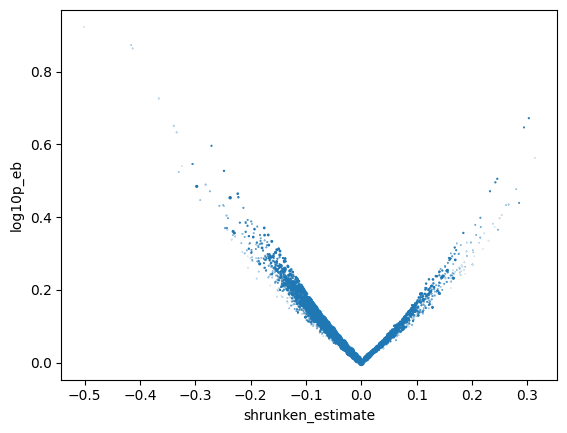

In [195]:
table.plot.scatter(x="shrunken_estimate", y="log10p_eb", s="weights")

In [196]:
table

,weights,n_eff,naive_estimate,naive_standard_error,shrunken_estimate,shrunken_se,z_naive,z_eb,p_naive,p_eb,log10p_naive,log10p_eb,B
'De Novo' AMP Biosynthetic Process (GO:0044208),0.114871,4.547772,0.181175,0.382619,0.085062,0.280650,0.473512,0.303091,0.635848,0.761821,0.196647,0.118147,0.538019
'De Novo' Post-Translational Protein Folding (GO:0051084),4.083138,7.129567,-0.186163,0.330009,-0.124072,0.257790,0.564114,0.481291,0.572676,0.630309,0.242091,0.200446,0.610214
2-Oxoglutarate Metabolic Process (GO:0006103),0.742625,3.510842,-0.057133,0.298017,-0.046768,0.241650,0.191712,0.193535,0.847968,0.846540,0.071621,0.072353,0.657495
3'-UTR-mediated mRNA Destabilization (GO:0061158),0.291221,2.526714,-0.024766,0.295705,-0.025479,0.240413,0.083751,0.105979,0.933254,0.915599,0.030000,0.038295,0.660993
3'-UTR-mediated mRNA Stabilization (GO:0070935),0.494394,1.948125,-0.102581,0.284165,-0.078247,0.234087,0.360992,0.334266,0.718106,0.738179,0.143812,0.131838,0.678598
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zinc Ion Import Across Plasma Membrane (GO:0071578),0.115105,2.302462,-0.213840,0.363609,-0.132177,0.272884,0.588104,0.484370,0.556463,0.628123,0.254564,0.201955,0.563232
Zinc Ion Import Into Organelle (GO:0062111),0.055883,2.489033,-0.196684,0.426861,-0.108956,0.296780,0.460768,0.367126,0.644965,0.713525,0.190464,0.146591,0.483389
Zinc Ion Transmembrane Transport (GO:0071577),0.360231,6.233409,-0.134539,0.332380,-0.092203,0.258916,0.404774,0.356113,0.685644,0.721756,0.163902,0.141610,0.606803
Zinc Ion Transport (GO:0006829),0.427175,7.407604,-0.119566,0.337267,-0.082470,0.261206,0.354516,0.315730,0.722952,0.752208,0.140890,0.123662,0.599816


In [ ]:
# empirical lfc and se
se = df["lfcSE"].values
lfc = df["log2FoldChange"].values

# Estimating Beta
custom = (df["baseMean"] * balanced_matrix.T)
variance_weighting = (1 / df["lfcSE"].pow(2))

# Correct
weights = (custom * variance_weighting).pipe(lambda d: d.div(d.sum(axis=1), axis=0))

normalized_estimate = (weights * df["log2FoldChange"]).sum(axis=1)

# Estimating sigma^2
custom_squared = (df["baseMean"] * balanced_matrix.T)
variance_weighting = (1 / df["lfcSE"].pow(2))

variance_weights = (custom * variance_weighting).pow(2)
variance_weights_normalized = (variance_weights).pipe(lambda d: d.div(d.sum(axis=1), axis=0))

normalized_standard_error = (variance_weights_normalized * df["lfcSE"]).sum(axis=1).apply(np.sqrt)

# Infer the Data Variance 
tau2_samples, mean_samples = MetaAnalysis.sample_tau2_likelihood(
    normalized_estimate, 
    normalized_standard_error.pow(2), 
    n_samples=5000, 
    prior_shape=1, 
    prior_rate=.1,
    mu_prior_mean=0, 
    mu_prior_var=0.01
)
# tau2 = np.mean(tau2_estimates[1000:])
tau2 = MetaAnalysis.mode_kde(tau2_samples[1000:])
full_dataset_mean = mean_samples[1000:].mean()

B = tau2 / (tau2 + normalized_standard_error.pow(2))

shrunken_estimate = (
    B * normalized_estimate +
    (1 - B) * full_dataset_mean
)

# compute the posterior covariance.
shrunken_variance = (1/((1/tau2) + 1/normalized_standard_error.pow(2)))
shrunken_standard_error = np.sqrt(shrunken_variance)

# stable_computation
z_naive = np.abs(normalized_estimate / normalized_standard_error)
z_eb = np.abs(shrunken_estimate / shrunken_standard_error)

log_p_naive = np.log(2) + norm.logsf(z_naive)
log_p_eb = np.log(2) + norm.logsf(z_eb)

p_naive = np.exp(log_p_naive)
p_eb = np.exp(log_p_eb)

log10p_naive = -log_p_naive / np.log(10)
log10p_eb = -log_p_eb / np.log(10)

table = pd.DataFrame({
    # Per Gene Statistics
    "weights": (df["baseMean"] * balanced_matrix.T).sum(axis=1),
    "n_eff": (weights.sum(axis=1).pow(2) / weights.pow(2).sum(axis=1)),

    # Naive Estimates
    "naive_estimate": normalized_estimate,
    "naive_standard_error": normalized_standard_error,
    
    # EB Estimates
    "shrunken_estimate": shrunken_estimate,
    "shrunken_se": shrunken_standard_error,

    # Z-scores
    "z_naive": z_naive,
    "z_eb": z_eb,

    # pvalues
    "p_naive": p_naive,
    "p_eb": p_eb,

    # log10 for plotting
    "log10p_naive": log10p_naive,
    "log10p_eb": log10p_eb,

    # Full Dataset Statistics
    "B": B,
})

In [216]:
precision = 1 / df["lfcSE"].pow(2)

weights = (custom * precision).pow(2)

weights_normalized = weights.div(weights.sum(axis=1), axis=0)

variance = (weights_normalized * df["lfcSE"].pow(2)).sum(axis=1)

normalized_standard_error = np.sqrt(variance)

In [217]:
normalized_standard_error

'De Novo' AMP Biosynthetic Process (GO:0044208)              0.147845
'De Novo' Post-Translational Protein Folding (GO:0051084)    0.109525
2-Oxoglutarate Metabolic Process (GO:0006103)                0.089256
3'-UTR-mediated mRNA Destabilization (GO:0061158)            0.088081
3'-UTR-mediated mRNA Stabilization (GO:0070935)              0.081029
                                                               ...   
Zinc Ion Import Across Plasma Membrane (GO:0071578)          0.133731
Zinc Ion Import Into Organelle (GO:0062111)                  0.193170
Zinc Ion Transmembrane Transport (GO:0071577)                0.112122
Zinc Ion Transport (GO:0006829)                              0.115765
Zymogen Activation (GO:0031638)                              0.081062
Length: 5213, dtype: float64